<a href="https://colab.research.google.com/github/alfitranurr/Remove-Background-Apps/blob/main/Remove_Background_Apps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Background Removal with `transparent-background`

This notebook demonstrates how to automatically remove backgrounds from images using the `transparent-background` Python library. It supports batch processing of images and leverages GPU acceleration if available.

## 1. Install Dependencies

First, we need to install the `transparent-background` library. This command will install the package and its required dependencies.

In [10]:
!pip install transparent-background

## 2. Import Libraries and Verify GPU

Next, we import all necessary Python libraries and verify that GPU (CUDA) is available, as the `transparent-background` library can utilize it for faster processing.

In [11]:
import os
import torch
from PIL import Image
from tqdm import tqdm
from transparent_background import Remover
from google.colab import files
import shutil

# Verify GPU
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
GPU: Tesla T4


## 3. Configure Directories

Define the input and output directories for the images. The `INPUT_DIR` is where you'll upload your images, and `OUTPUT_DIR` is where the processed images with transparent backgrounds will be saved.

In [12]:
INPUT_DIR = "images"
OUTPUT_DIR = "remove-bg"

# Create directories if they don't exist
os.makedirs(INPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 4. Initialize Background Remover

Initialize the `Remover` model. This step will automatically detect and use a GPU if available, or fall back to CPU if not.

In [13]:
# Initialize background remover (automatically uses GPU if available)
remover = Remover()

Settings -> Mode=base, Device=cuda:0, Torchscript=disabled


## 5. Upload Images for Processing

Use the `files.upload()` function to upload images from your local machine. The uploaded images will be moved to the specified `INPUT_DIR`.

In [14]:
# Upload files
uploaded = files.upload()

# Move uploaded files to INPUT_DIR
for filename in uploaded.keys():
    shutil.move(filename, os.path.join(INPUT_DIR, filename))
    print(f'Moved {filename} to {INPUT_DIR}/')

print(f'Successfully uploaded {len(uploaded)} files to {INPUT_DIR}/')

Saving Riko PDH.JPG to Riko PDH.JPG
Saving Meme PDH.JPG to Meme PDH.JPG
Saving Dhani PDH.JPG to Dhani PDH.JPG
Moved Riko PDH.JPG to images/
Moved Meme PDH.JPG to images/
Moved Dhani PDH.JPG to images/
Successfully uploaded 3 files to images/


## 6. Process Images and Remove Backgrounds

This section iterates through all images in the `INPUT_DIR`, processes them using the `remover` model to create a transparent background, and saves the resulting RGBA images (with transparency) to the `OUTPUT_DIR`.

In [21]:
# Process all images
image_files = sorted([
    f for f in os.listdir(INPUT_DIR)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

if not image_files:
    print(f"No image files found in {INPUT_DIR}. Please upload images in the previous step.")
else:
    for idx, filename in enumerate(tqdm(image_files), start=1):
        input_path = os.path.join(INPUT_DIR, filename)
        output_filename = os.path.splitext(filename)[0] # Get original name without extension
        output_path = os.path.join(OUTPUT_DIR, f"{output_filename}_transparent.png")

        # Load image, apply EXIF orientation, then convert to RGB
        img = Image.open(input_path)
        img = ImageOps.exif_transpose(img) # Apply EXIF orientation
        img = img.convert("RGB")

        result = remover.process(img, type='rgba') # Returns RGBA
        result.save(output_path)

    print("\n✅ All images processed successfully! Check the 'remove-bg' directory for results.")

100%|██████████| 3/3 [00:11<00:00,  3.96s/it]


✅ All images processed successfully! Check the 'remove-bg' directory for results.


## 7. View Processed Files

You can list the files in the `OUTPUT_DIR` to see the names of the images with transparent backgrounds.

In [16]:
print(f"Files in '{OUTPUT_DIR}':")
for f in os.listdir(OUTPUT_DIR):
    print(f)

Files in 'remove-bg':
image_2.png
Riko PDH_transparent.png
Meme PDH_transparent.png
Dhani PDH_transparent.png
image_1.png


## 8. Visualize Before & After

Let's display some of the original images alongside their processed versions to see the background removal in action.

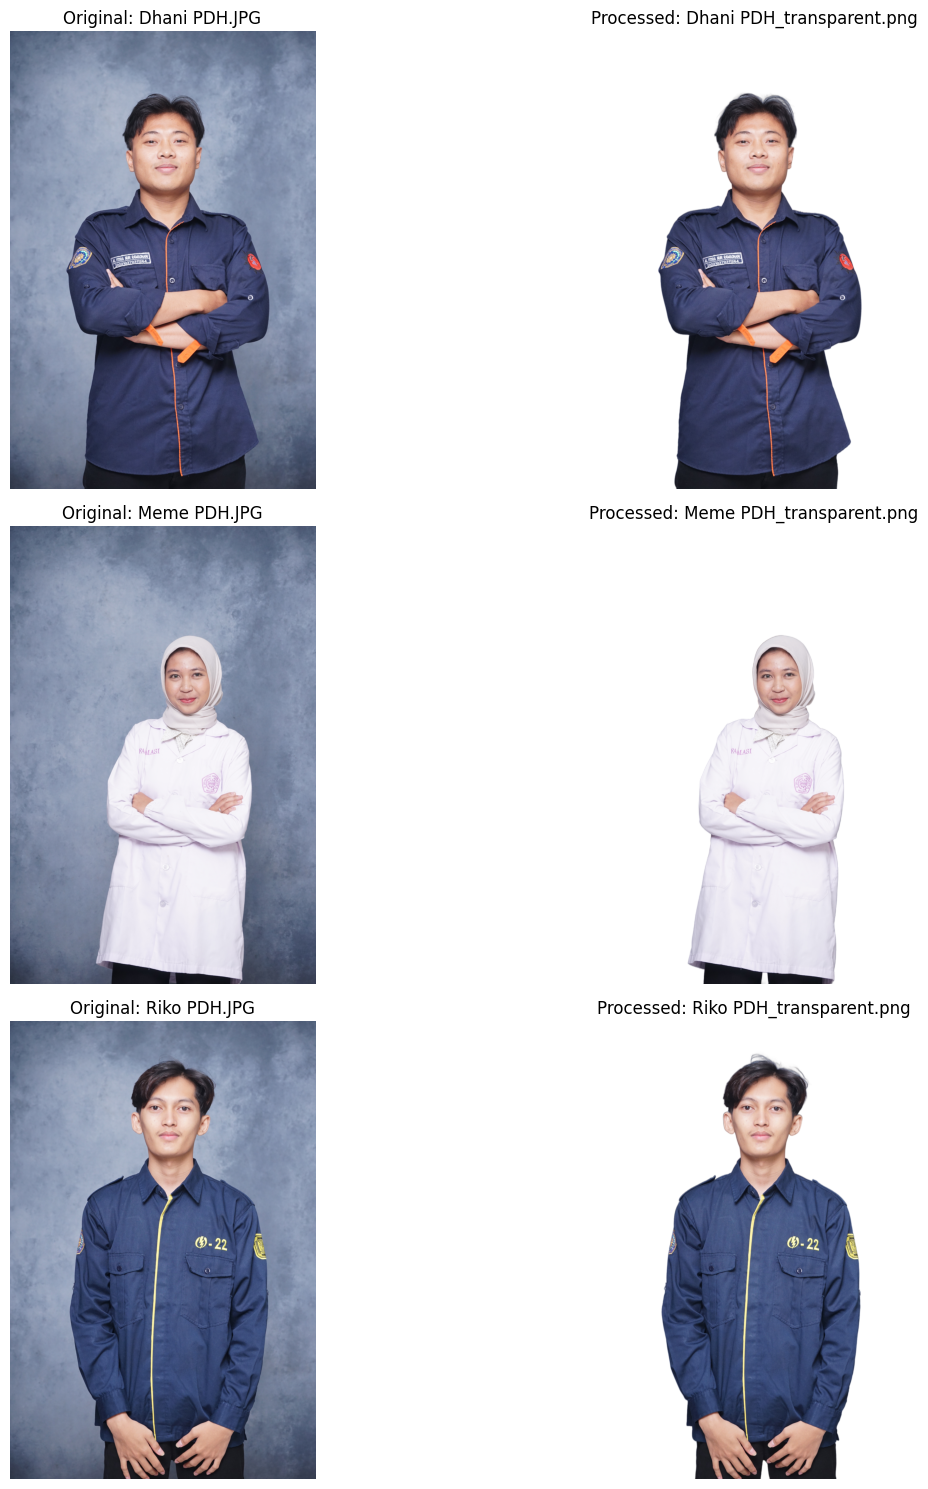

In [22]:
import matplotlib.pyplot as plt
from PIL import Image, ImageOps # Import ImageOps for EXIF orientation
import os

# Get list of original image files
original_image_files = sorted([f for f in os.listdir(INPUT_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

if not original_image_files:
    print("No original images found to display.")
else:
    plt.figure(figsize=(15, 5 * len(original_image_files)))

    for i, filename in enumerate(original_image_files):
        original_path = os.path.join(INPUT_DIR, filename)
        output_filename_base = os.path.splitext(filename)[0]
        processed_path = os.path.join(OUTPUT_DIR, f"{output_filename_base}_transparent.png")

        # Load original image and apply EXIF orientation
        original_img = Image.open(original_path)
        original_img = ImageOps.exif_transpose(original_img) # Apply EXIF orientation

        # Load processed image and apply EXIF orientation
        if os.path.exists(processed_path):
            processed_img = Image.open(processed_path)
            processed_img = ImageOps.exif_transpose(processed_img) # Apply EXIF orientation
        else:
            processed_img = Image.new('RGBA', original_img.size, (0, 0, 0, 0)) # Create a blank transparent image if not found

        # Display original image
        plt.subplot(len(original_image_files), 2, 2*i + 1)
        plt.imshow(original_img)
        plt.title(f"Original: {filename}")
        plt.axis('off')

        # Display processed image
        plt.subplot(len(original_image_files), 2, 2*i + 2)
        plt.imshow(processed_img)
        plt.title(f"Processed: {output_filename_base}_transparent.png")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

---